In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [58]:
feature_names = [
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness",
    "concavity",
    "concave_points",
    "symmetry",
    "fractal_dimension"
]

columns = ["id", "diagnosis"]
for group in ["mean", "se", "worst"]:
    for feature in feature_names:
        columns.append(f"{feature}_{group}")

data = pd.read_csv("wdbc.data", header=None, names=columns)
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [59]:
dataset_summary = pd.DataFrame({
    "Rows": [data.shape[0]],
    "Columns": [data.shape[1]],
    "Missing Values": [data.isna().sum().sum()],
    "Duplicate Rows": [data.duplicated().sum()]
})

class_distribution = data["diagnosis"].value_counts().rename(index={"B": "Benign", "M": "Malignant"})

display(dataset_summary)
display(class_distribution.to_frame("Count"))

,Rows,Columns,Missing Values,Duplicate Rows
0,569,32,0,0


,Count
diagnosis,
Benign,357
Malignant,212


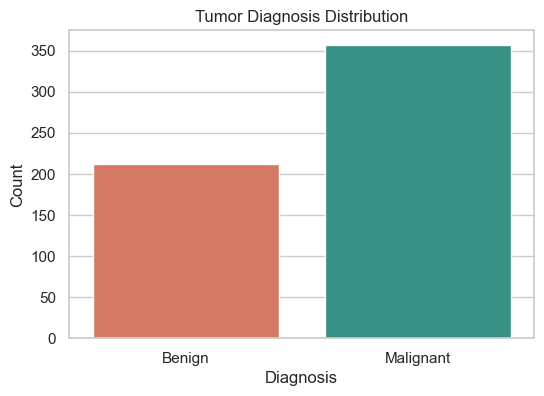

In [60]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="diagnosis", hue="diagnosis", palette={"B": "#2a9d8f", "M": "#e76f51"}, legend=False)
plt.xticks([0, 1], ["Benign", "Malignant"])
plt.title("Tumor Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

In [61]:
X = data.drop(columns=["id", "diagnosis"])
y = data["diagnosis"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

pd.DataFrame({
    "Training Samples": [X_train.shape[0]],
    "Testing Samples": [X_test.shape[0]],
    "Features": [X_train.shape[1]]
})

,Training Samples,Testing Samples,Features
0,455,114,30


In [62]:
models = {
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Artificial Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", max_iter=1000, random_state=42))
    ])
}

models["Ensemble Learning"] = VotingClassifier(
    estimators=[
        ("svm", models["Support Vector Machine"]),
        ("rf", models["Random Forest"]),
        ("gb", models["Gradient Boosting"]),
        ("ann", models["Artificial Neural Network"])
    ],
    voting="soft"
)

list(models.keys())

['Support Vector Machine',
 'Random Forest',
 'Gradient Boosting',
 'Artificial Neural Network',
 'Ensemble Learning']

In [63]:
results = []
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    trained_models[name] = model
    predictions[name] = y_pred
    probabilities[name] = y_proba
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Support Vector Machine,0.973684,1.0,0.928571,0.962963,0.994709
1,Random Forest,0.964912,1.0,0.904762,0.950000,0.994213
2,Gradient Boosting,0.964912,1.0,0.904762,0.950000,0.994709
3,Artificial Neural Network,0.964912,1.0,0.904762,0.950000,0.992725
4,Ensemble Learning,0.964912,1.0,0.904762,0.950000,0.996362


In [64]:
best_model_name = results_df.loc[0, "Model"]
best_predictions = predictions[best_model_name]

print("Best Model:", best_model_name)
print(classification_report(y_test, best_predictions, target_names=label_encoder.classes_))

Best Model: Support Vector Machine
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



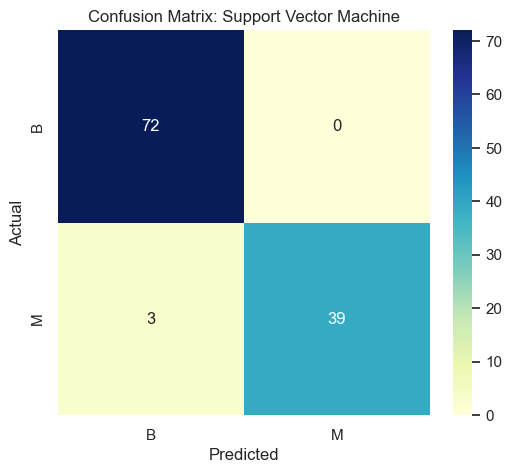

In [65]:
best_matrix = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(best_matrix, annot=True, fmt="d", cmap="YlGnBu", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

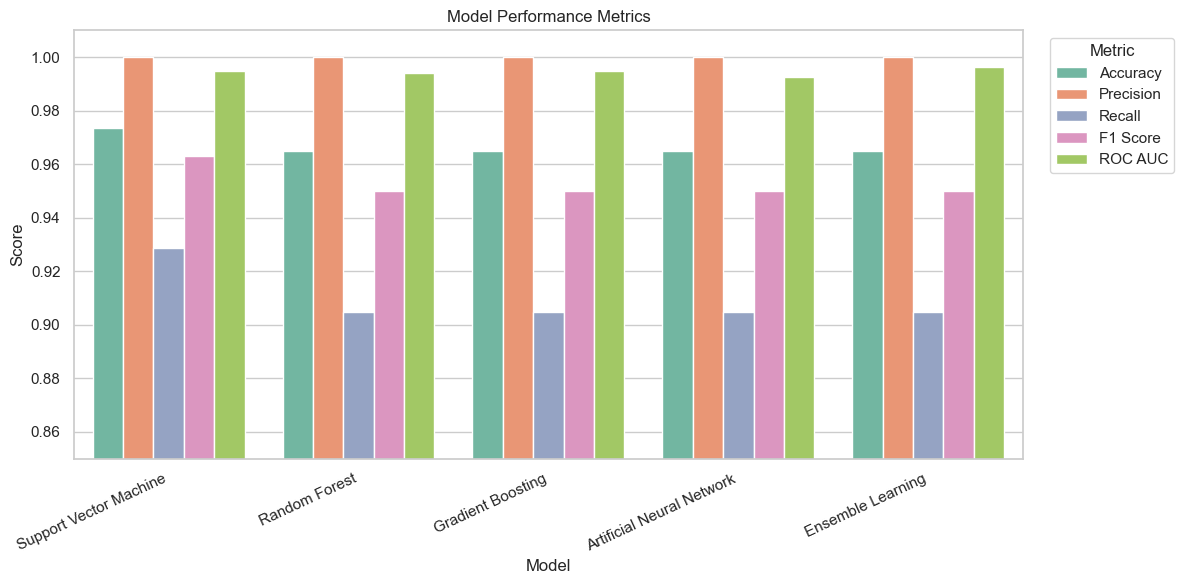

In [66]:
plot_results = results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"])

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_results, x="Model", y="value", hue="variable", palette="Set2")
plt.title("Model Performance Metrics")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

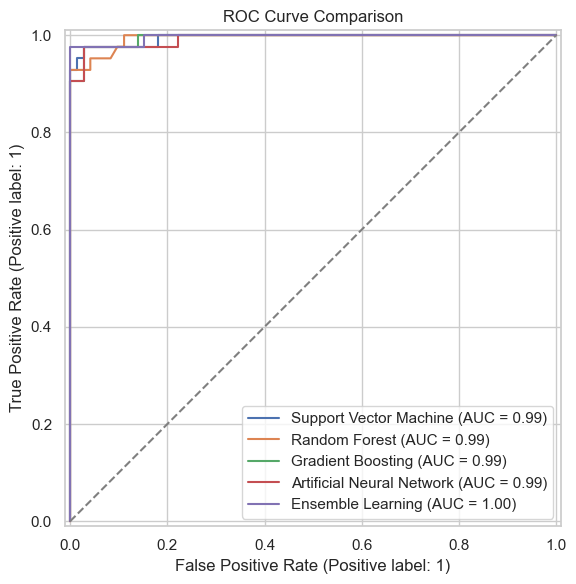

In [67]:
plt.figure(figsize=(8, 6))

for name, y_proba in probabilities.items():
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=plt.gca())

plt.title("ROC Curve Comparison")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.tight_layout()
plt.show()

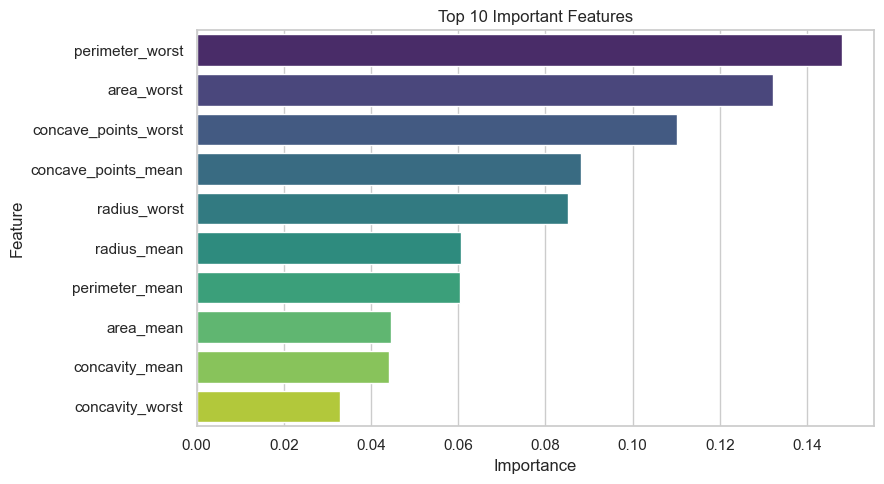

,Feature,Importance
22,perimeter_worst,0.147912
23,area_worst,0.132269
27,concave_points_worst,0.110114
7,concave_points_mean,0.088200
20,radius_worst,0.085116
0,radius_mean,0.060554
2,perimeter_mean,0.060465
3,area_mean,0.044701
6,concavity_mean,0.044091
26,concavity_worst,0.032828


In [68]:
forest_model = trained_models["Random Forest"]
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis", hue="Feature", legend=False)
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df

In [69]:
sample_patient = X_test.iloc[[0]]
sample_prediction = trained_models[best_model_name].predict(sample_patient)[0]
sample_probability = trained_models[best_model_name].predict_proba(sample_patient)[0]

pd.DataFrame({
    "Predicted Diagnosis": [label_encoder.inverse_transform([sample_prediction])[0]],
    "Benign Probability": [sample_probability[0]],
    "Malignant Probability": [sample_probability[1]]
})

,Predicted Diagnosis,Benign Probability,Malignant Probability
0,B,0.998373,0.001627


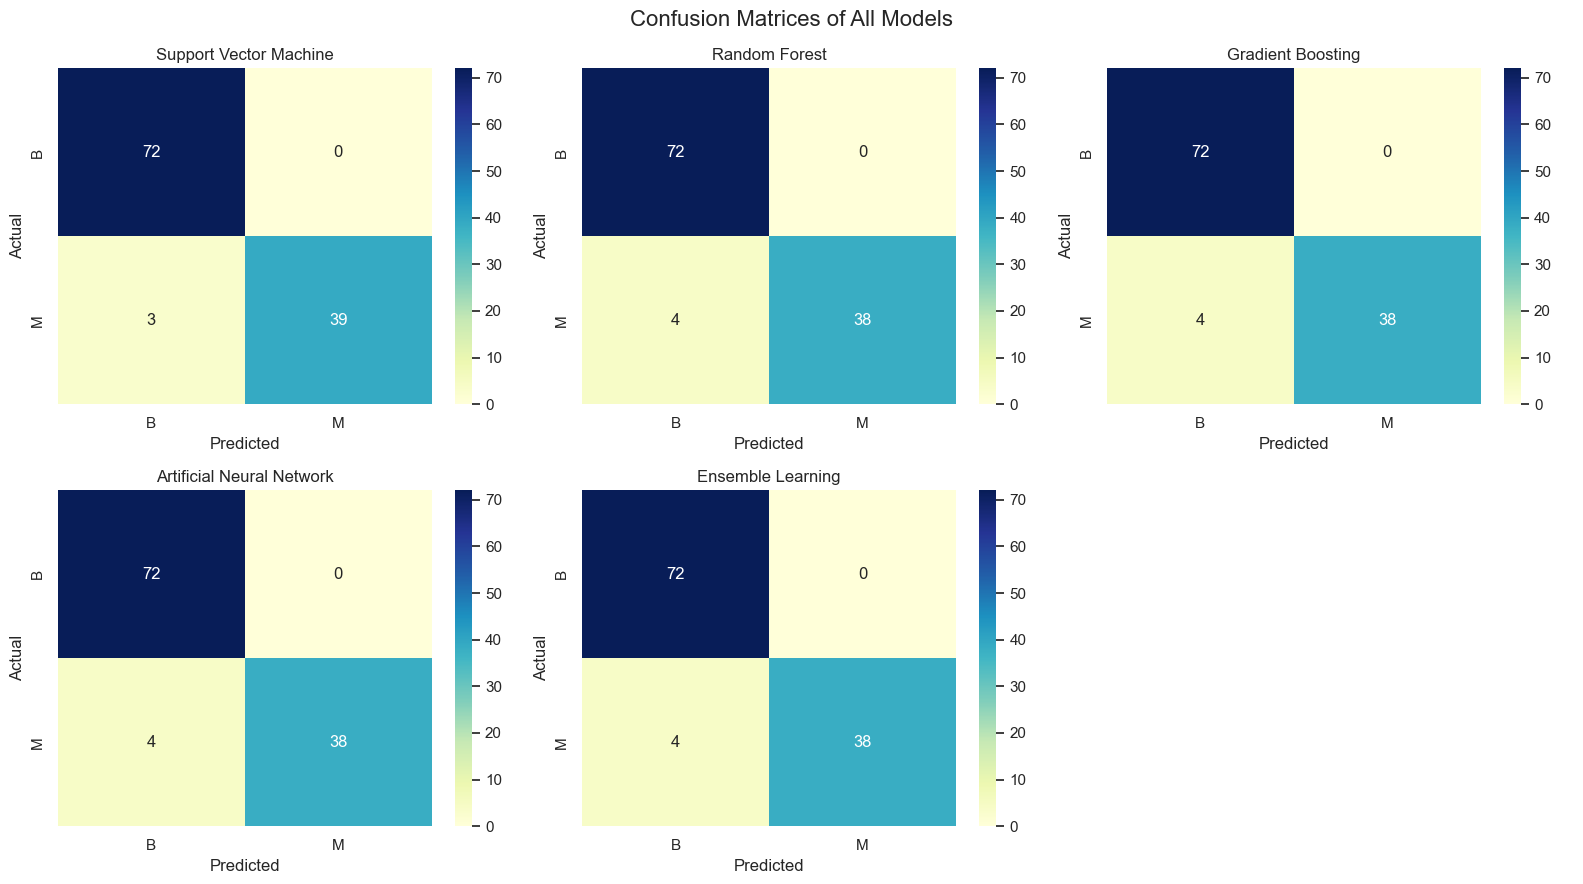

In [70]:
model_names = list(predictions.keys())
rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(16, 9))
axes = axes.flatten()

for index, name in enumerate(model_names):
    matrix = confusion_matrix(y_test, predictions[name])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[index])
    axes[index].set_title(name)
    axes[index].set_xlabel("Predicted")
    axes[index].set_ylabel("Actual")

for index in range(len(model_names), len(axes)):
    axes[index].axis("off")

plt.suptitle("Confusion Matrices of All Models", fontsize=16)
plt.tight_layout()
plt.show()

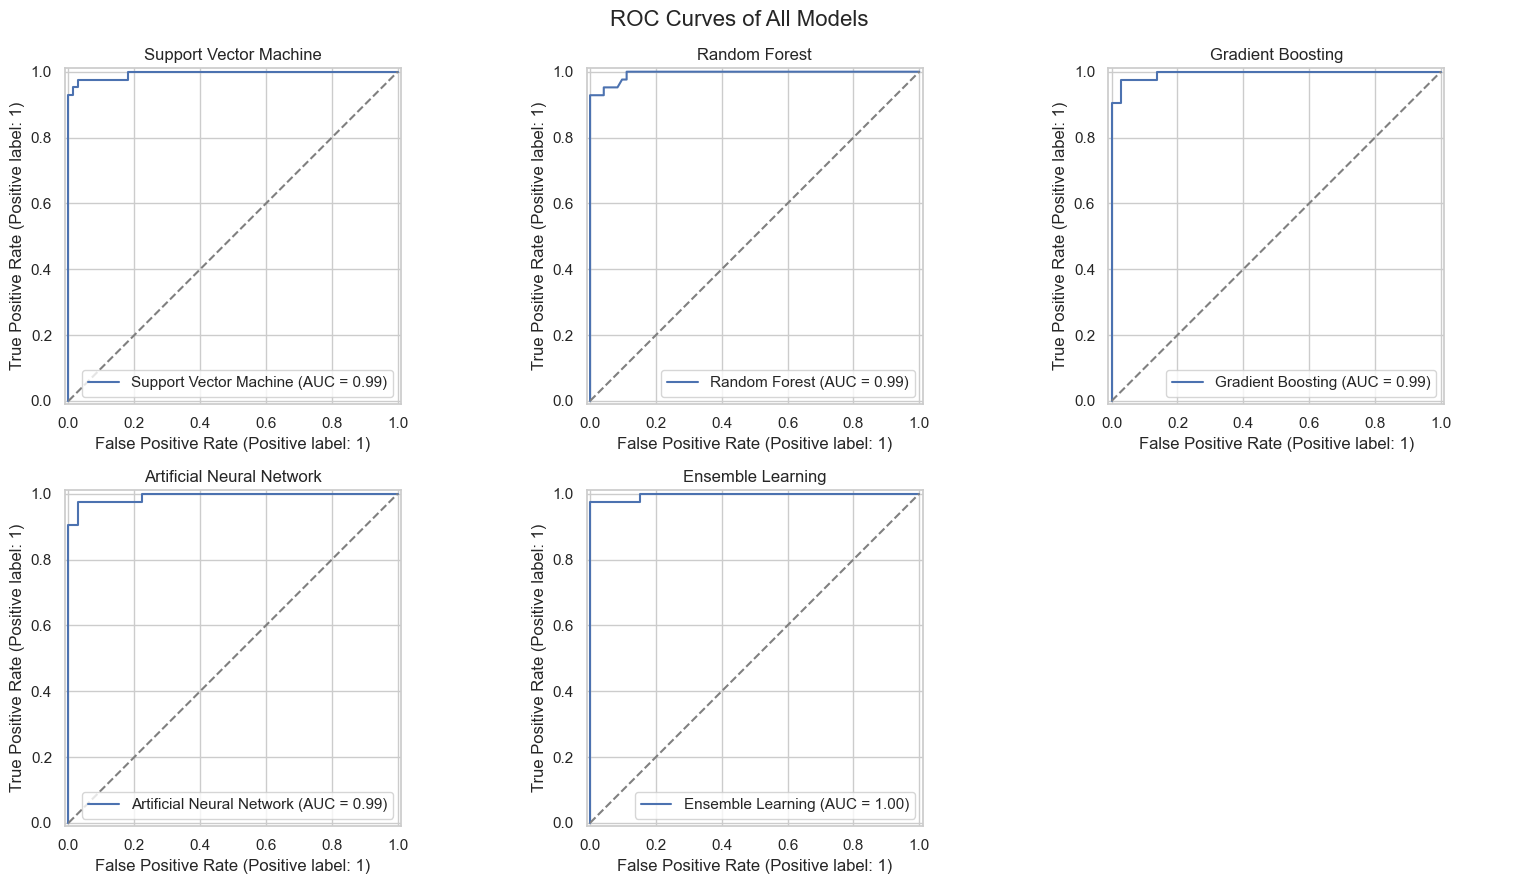

In [71]:
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))
axes = axes.flatten()

for index, name in enumerate(model_names):
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name, ax=axes[index])
    axes[index].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[index].set_title(name)

for index in range(len(model_names), len(axes)):
    axes[index].axis("off")

plt.suptitle("ROC Curves of All Models", fontsize=16)
plt.tight_layout()
plt.show()